In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Deck 5 figures — corrected

Three figures from `figs4deck5.ipynb`, rebuilt after two corrections. Everything is
**post-processing**: `data/**/scores.csv` is read and never written.

| correction | what it does | which figure it moves |
|---|---|---|
| **PMI offset `C`** | every stored margin is the raw margin minus one constant per model. It lands in the intercept, so it *is* the fitted positional bias. Recovered here and added back. | **12.1** (the whole point) |
| **Position correction** | every "who wins" question is answered from `D = (m(x,y) - m(y,x))/2`, which cancels the positional bias and `C` exactly. | **5.5 D** |
| **Metric choice** | adherence is reported both as a *behaviour* (win rate) and as a *preference change* (`kappa`), because they disagree. | **5.5 D** |

Feature weights are **untouched** by either correction — a constant cannot move them
(it goes entirely into the intercept). So **Fig 6.2 is expected to be identical** to the
original, and reproducing it is a check that the new code path agrees with the old one.

**The frame is pinned to `shopping` throughout.** Every constrained run uses that frame and the
`bare` runs exist only unconstrained, so a contract comparison has to hold the frame fixed — a
`bare` baseline against `shopping` contracts would vary two things at once. Since the bare runs
landed, `constraints_id` alone is no longer a unique run key (it is `"none"` for both), so the
loader filters on frame and asserts uniqueness.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerTuple

SAVE = True
FIGDIR = "figs/deck5_fix"          # separate dir: the original deck5 figures stay as they are
os.makedirs(FIGDIR, exist_ok=True)

BASES = ["data/laptops_robustness", "data/laptops_robustness_gemma"]
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SC = ["13-inch", "14-inch", "16-inch"]
RM = ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
cols = [CLAB[c] for c in CON]
SIZES = {"qwen": ["0.5", "7", "32", "72"], "gemma": ["1", "4", "12", "27"]}
ALL = [(f, s) for f in SIZES for s in SIZES[f]]
# qwen-0.5B is noise on every measure - kept only where its being noise is the point.
REAL = [("qwen", s) for s in ["7", "32", "72"]] + [("gemma", s) for s in SIZES["gemma"]]
def lbl(f, s): return f"{f}-{s}B"

BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
FAM_COLOR = {"qwen": "#2a78d6", "gemma": "#eb6834"}
SATISFY, VIOLATE, GAMMA_C = "#2a78d6", "#e34948", "#52514e"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": "#e8e7e3", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
    "font.size": 10, "savefig.bbox": "tight", "savefig.dpi": 200,
})
pd.set_option("display.width", 220)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig

## Notation

**One row = one ordered pair.** The model sees option A and option B and returns two
log-probabilities. What is stored is `score_a`, `score_b`; the quantity we use is the margin

$$m(a,b) = \text{score}_a - \text{score}_b .$$

**Bradley-Terry with a positional bias.** Writing $u$ for the utility of a laptop and
$\gamma$ for the bias that comes from *being in slot A* rather than from the laptop:

$$m_{\text{raw}}(a,b) = \gamma + u(a) - u(b) + \varepsilon,
\qquad u(x) = \sum_f w_f(x_f), \qquad \sum_{\ell} w_f(\ell) = 0 .$$

The zero-sum condition per feature means a weight reads as *above / below the average level
of that feature*, and no level is an arbitrary reference point.

### The PMI offset

Every run so far was collected with `normalize_pmi=True`, which subtracts the score of the
bare base context — always the literal string `"Answer: "`. So what is on disk is

$$m_{\text{stored}}(a,b) = m_{\text{raw}}(a,b) - C,
\qquad C = \log P(L_1 \mid \text{base}) - \log P(L_2 \mid \text{base}),$$

one constant per model. Three consequences, and they are not the same:

| quantity | effect of $C$ |
|---|---|
| feature weights $w_f(\ell)$ | **none** — a constant lands entirely in the intercept |
| positional bias $\gamma$ | **fully corrupted** — the fitted intercept is $\gamma - C$ |
| any test of the form $m > 0$ | **corrupted** — the decision threshold is $C$, not $0$ |

**Recovering $C$.** When the model is saturated on some prompt, $\log P(L \mid \text{prompt}) \to 0$,
so the largest stored score for that option is $-\log P(L \mid \text{base})$. Hence

$$\hat{C} = \max_i \text{score}_b^{(i)} - \max_i \text{score}_a^{(i)},
\qquad\text{and}\qquad \hat{\gamma} = \hat{\gamma}_{\text{fit}} + \hat{C} .$$

This needs the model to actually saturate. Seven of the eight do, on thousands of rows;
**qwen-0.5B never does**, so its $C$ is not recoverable from the stored data and its
$\gamma$ is reported as unknown.

### Position correction

Every unordered pair $\{x,y\}$ is shown in **both** slot orders. Averaging the two removes
the slot effect exactly, whatever it is:

$$D(x,y) = \tfrac{1}{2}\left[\, m(x,y) - m(y,x) \,\right] = u(x) - u(y).$$

$D$ is immune to $\gamma$, to $C$, and to any other constant, so it needs no PMI fix at all.
It is the right quantity for every "which one does the model pick?" question.

### The two adherence metrics

The contract names feature $f$ and asks for level $\ell^{*}$. Its rival $\ell'$ is the level the
model prefers on its own. Over the set $S$ of pairs that differ **only** in $f$, one side
$\ell^{*}$ and the other $\ell'$:

$$A = \frac{100}{|S|}\sum_{\{x,y\} \in S} \mathbf{1}\!\left[\, D(x,y) > 0 \,\right]
\qquad\text{(behaviour: how often the asked-for level wins)}$$

$$g = \frac{1}{|S|}\sum_{\{x,y\} \in S} D(x,y)
\qquad\text{(preference: by how much, in log-odds)}$$

$$\kappa = 1 - \frac{g_1}{g_0}
\qquad\text{(how much of its own preference the contract cancelled)}$$

with $g_0$ from the no-contract run and $g_1$ from the contract run. $\kappa = 0$ means the
contract did nothing, $\kappa = 1$ means the model is now exactly indifferent, $\kappa > 1$
means the preference flipped sign. Because $\kappa$ is a ratio of two gaps from the *same*
model, the weight scale — a nuisance parameter here — cancels.

$A$ saturates at 0 and 100 and cannot show *how hard* a preference was overridden; $\kappa$
can, but it explodes when $g_0 \approx 0$ (nothing to cancel). Both are reported.

## Load the runs, and recover the PMI offset

`C` depends only on the model, not on the contract, so it is estimated once per model by
pooling that model's four runs (a tighter bound than any single run gives). The saturation
column is the share of rows sitting at the maximum — the assumption behind the estimate.

In [3]:
# The frame is held FIXED across everything compared here.
#
# Every constrained run ever collected uses the "shopping" frame, and the `bare` runs exist
# only unconstrained. So a contract comparison must pin the frame to "shopping" - otherwise
# the "no contract" baseline would differ from the contract runs in TWO ways at once (no
# contract AND no frame sentence), and the frame by itself moves brand weights by up to
# 4.6 log-odds (progress.md 2026-08-16).
#
# It also fixes a real collision: `constraints_id` is "none" for both the shopping and the
# bare unconstrained run, so (family, size, constraints_id) stopped being a unique key the
# day the bare runs landed. The assert makes any future collision loud instead of silent.
FRAME = "shopping"


def load(frame=FRAME):
    """Runs on the `frame` frame, keyed by (family, size, constraints_id).
    scores.csv is read, never written."""
    R, K = {}, {}
    for base in BASES:
        for run in sorted(os.listdir(base)):
            cp = os.path.join(base, run, "config.json")
            if not os.path.isfile(cp):
                continue
            c = json.load(open(cp))
            if c["frame"]["name"] != frame or c["constraints_id"] not in CON:
                continue
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            assert key not in R, f"two runs share the key {key}; the key is not unique"
            R[key] = pd.read_csv(os.path.join(base, run, "scores.csv"))
            K[key] = c["constraints"]
    return R, K


def pmi_offset(runs, tol=0.01, min_sat=0.01):
    """C = logP(L1|base) - logP(L2|base), recovered from saturation.

    A saturated prompt has logP(L|prompt) ~ 0, so max(score) ~ -logP(L|base).
    Returns (C, saturation_share). C is NaN when the model never saturates, in which
    case max(score) is nowhere near -logP(L|base) and the estimate is meaningless.
    """
    mA = max(d.score_a.max() for d in runs)
    mB = max(d.score_b.max() for d in runs)
    sat = min(max((d.score_a > mA - tol).mean() for d in runs),
              max((d.score_b > mB - tol).mean() for d in runs))
    return (mB - mA if sat >= min_sat else np.nan), sat


RUNS, CONSTRAINTS = load()
print(f"frame pinned to {FRAME!r}: {len(RUNS)} runs\n")
PMI_C, SAT = {}, {}
for fam, s in ALL:
    rs = [RUNS[(fam, s, c)] for c in CON]
    PMI_C[(fam, s)], SAT[(fam, s)] = pmi_offset(rs)

print(f"{len(RUNS)} runs loaded ({len(ALL)} models x {len(CON)} contracts)\n")
print(pd.DataFrame([dict(model=lbl(f, s), C=PMI_C[(f, s)], saturation=SAT[(f, s)])
                    for f, s in ALL]).round(3).to_string(index=False))
print("\nC is NaN where the model never saturates -> its positional bias is not recoverable.")

frame pinned to 'shopping': 32 runs

32 runs loaded (8 models x 4 contracts)

    model      C  saturation
qwen-0.5B    NaN       0.000
  qwen-7B  6.001       0.403
 qwen-32B  2.250       0.413
 qwen-72B  5.625       0.412
 gemma-1B 10.468       0.340
 gemma-4B 10.500       0.495
gemma-12B  9.749       0.462
gemma-27B  5.243       0.497

C is NaN where the model never saturates -> its positional bias is not recoverable.


## The model: `FeatureBT`

Imported from [src/bt.py](../src/bt.py) — one definition shared by every notebook. Weights are
centred per feature and the positional bias is kept separate from the laptops. Pass the
recovered `pmi_c` and `gamma_` is the corrected bias; `beta0_` (alias `gamma_fit_`) always holds
the raw intercept, so both stay visible.

In [4]:
from src.bt import FeatureBT   # single source of truth, see src/bt.py

FITS = {k: FeatureBT(pmi_c=PMI_C[k[:2]]).fit(d) for k, d in RUNS.items()}
print(f"{len(FITS)} fits.  R^2 range: "
      f"{min(f.r2_ for f in FITS.values()):.3f} - {max(f.r2_ for f in FITS.values()):.3f}")
print("\nPositional bias, unconstrained runs (log-odds):")
print(pd.DataFrame([dict(model=lbl(f, s), gamma_fitted=FITS[(f, s, "none")].gamma_fit_,
                         C=PMI_C[(f, s)], gamma_corrected=FITS[(f, s, "none")].gamma_)
                    for f, s in ALL]).round(2).to_string(index=False))

/home/lotanamit/WhatDoLLMsWant/src/bt.py:108: UserWarning: low fit: R^2 = 0.307 < 0.5
  warnings.warn(f"low fit: R^2 = {self.r2_:.3f} < {self.r2_warn}")
/home/lotanamit/WhatDoLLMsWant/src/bt.py:108: UserWarning: low fit: R^2 = 0.386 < 0.5
  warnings.warn(f"low fit: R^2 = {self.r2_:.3f} < {self.r2_warn}")
/home/lotanamit/WhatDoLLMsWant/src/bt.py:108: UserWarning: low fit: R^2 = 0.085 < 0.5
  warnings.warn(f"low fit: R^2 = {self.r2_:.3f} < {self.r2_warn}")


32 fits.  R^2 range: 0.085 - 0.924

Positional bias, unconstrained runs (log-odds):
    model  gamma_fitted     C  gamma_corrected
qwen-0.5B         -0.22   NaN              NaN
  qwen-7B         -9.05  6.00            -3.05
 qwen-32B         -6.98  2.25            -4.73
 qwen-72B         -9.44  5.62            -3.81
 gemma-1B         -6.94 10.47             3.53
 gemma-4B         -8.51 10.50             1.99
gemma-12B        -10.52  9.75            -0.77
gemma-27B         -7.83  5.24            -2.59


## Position-corrected pair helpers

`paired_D` is the one function every "who wins" number below goes through. It matches each
unordered pair across its two slot orders and returns one $D$ per pair, so the positional
bias and the PMI constant are gone before anything is counted.

In [5]:
def paired_D(d, mask, a_is_candidate):
    """One D = u(candidate) - u(other) per unordered pair, position-corrected.

    Each unordered pair appears twice, once per slot order:
        candidate in slot A:  +m = u_c - u_o + gamma
        candidate in slot B:  -m = u_c - u_o - gamma
    so the mean of the two is u_c - u_o. Immune to gamma, to the PMI constant C, and to
    any other additive constant. Pairs not seen in both orders are dropped.
    """
    m = (d.score_a - d.score_b).values
    A = (d.a_brand + "|" + d.a_screen + "|" + d.a_ram).values
    B = (d.b_brand + "|" + d.b_screen + "|" + d.b_ram).values
    first, second = np.where(A < B, A, B), np.where(A < B, B, A)
    key = np.char.add(np.char.add(first.astype(str), "##" + second.astype(str)),
                      "##" + d.template_idx.astype(str).values)
    t = pd.DataFrame({"key": key, "v": np.where(a_is_candidate, m, -m)})[np.asarray(mask)]
    g = t.groupby("key")["v"].agg(["mean", "size"])
    return g[g["size"] == 2]["mean"].values


def winrate(d, mask, a_is_candidate):
    """A: % of unordered pairs the candidate wins."""
    D = paired_D(d, mask, a_is_candidate)
    return 100 * float((D > 0).mean()) if len(D) else np.nan


def gap(d, mask, a_is_candidate):
    """g: mean position-corrected margin, in log-odds. Measured on THESE pairs only,
    so unlike a gap read off the fitted weights it assumes nothing about additivity."""
    D = paired_D(d, mask, a_is_candidate)
    return float(D.mean()) if len(D) else np.nan


def only_one(d, feat):
    """Rows where a and b differ in `feat` and are tied on every other feature."""
    m = (d[f"a_{feat}"] != d[f"b_{feat}"]).values.copy()
    for o in [f for f in ("brand", "screen", "ram") if f != feat]:
        m &= (d[f"a_{o}"] == d[f"b_{o}"]).values
    return m


def pair_of(d, feat, u, v):
    """Rows whose `feat` values are exactly {u, v}, in either order."""
    return (((d[f"a_{feat}"] == u) & (d[f"b_{feat}"] == v))
            | ((d[f"a_{feat}"] == v) & (d[f"b_{feat}"] == u))).values

---
# Fig 5.5 D — adherence, split into the two directions a contract creates

**The idea.** A contract that says *8GB* creates two very different comparisons, and averaging
them hides the only informative one:

| direction | pair | what obeying costs |
|---|---|---|
| **AGREE** | 8GB vs 4GB | nothing — the contract and the model's own taste want the same laptop |
| **CONFLICT** | 8GB vs 16GB | a RAM step — the model must give up something it wants |

**Which pairs.** *Ceteris paribus*: brand tied, the other spec feature tied, so the named
feature is the only thing that differs. 5 brands x 3 levels of the other feature x 5 templates
= **75 unordered pairs** (150 rows) per bar.

| contract | asked $\ell^{*}$ | agree pair | conflict pair |
|---|---|---|---|
| `screen=14-inch` | 14-inch | 14-inch vs 13-inch | 14-inch vs 16-inch |
| `ram=8GB` | 8GB | 8GB vs 4GB | 8GB vs 16GB |

**How to read it.** Bar height is $A$, the share of pairs won by the asked-for level, computed
from $D$ so no positional bias or PMI constant is left in it. 50% is "the contract changed
nothing"; the red tick is the *same conflict pairs with no contract*, i.e. where the model
started. The printed table adds $g_0 \to g_1$ and $\kappa$ for the conflict direction.

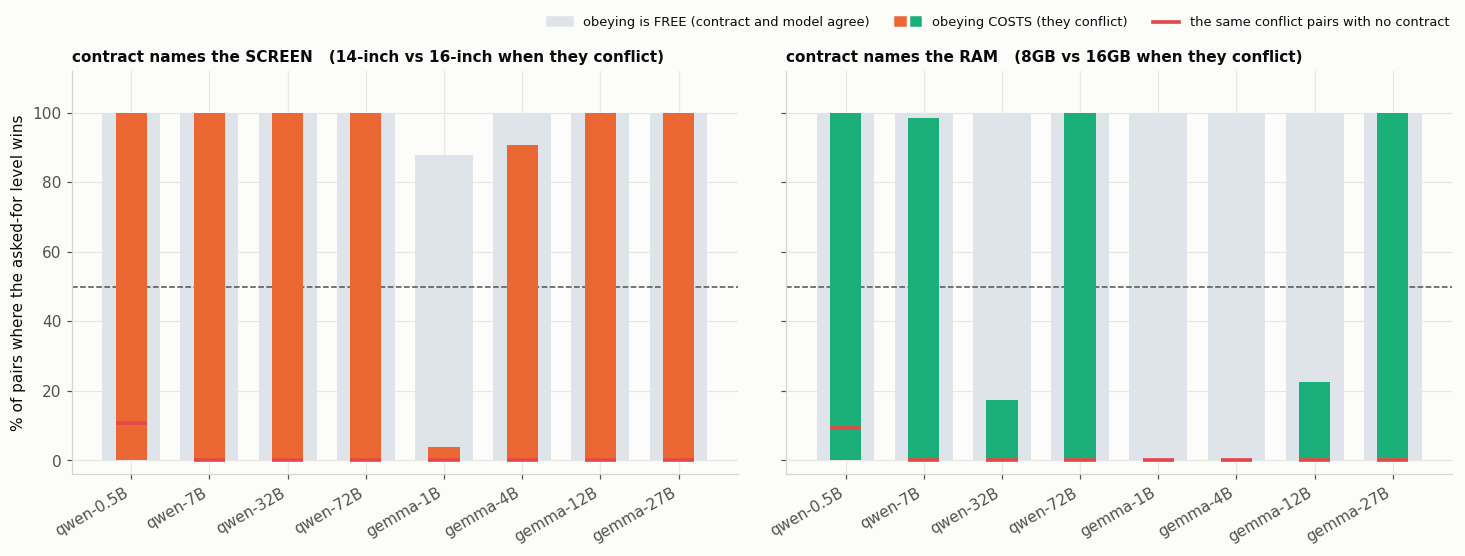

                  n_pairs  before  conflict  agree     g0     g1  kappa
model     feat                                                         
qwen-0.5B screen       75   10.67    100.00  100.0  -0.04   0.35  10.48
          ram          75    9.33    100.00  100.0  -0.04   0.63  16.33
qwen-7B   screen       75    0.00    100.00  100.0 -10.68  16.78   2.57
          ram          75    0.00     98.67  100.0 -21.38   9.02   1.42
qwen-32B  screen       75    0.00    100.00  100.0 -10.07  26.02   3.58
          ram          75    0.00     17.33  100.0 -27.35  -2.56   0.91
qwen-72B  screen       75    0.00    100.00  100.0  -7.80  21.24   3.72
          ram          75    0.00    100.00  100.0 -20.35  12.99   1.64
gemma-1B  screen       75    0.00      4.00   88.0  -4.89  -6.54  -0.34
          ram          75    0.00      0.00  100.0 -12.32 -10.98   0.11
gemma-4B  screen       75    0.00     90.67  100.0 -12.41   5.62   1.45
          ram          75    0.00      0.00  100.0 -20.21 -11.83

In [6]:
ASKED   = {"screen": "14-inch", "ram": "8GB"}
RIVAL   = {"screen": "16-inch", "ram": "16GB"}     # conflict: the model's own favourite
FRIEND  = {"screen": "13-inch", "ram": "4GB"}      # agree: obeying is free
RUN_OF  = {"screen": "screen=14-inch", "ram": "ram=8GB"}

rows = []
for fam, s in ALL:
    for feat in ("screen", "ram"):
        d1, d0 = RUNS[(fam, s, RUN_OF[feat])], RUNS[(fam, s, "none")]
        w1 = (d1[f"a_{feat}"] == ASKED[feat]).values     # is slot A the asked-for level?
        w0 = (d0[f"a_{feat}"] == ASKED[feat]).values
        agree_m1 = only_one(d1, feat) & pair_of(d1, feat, ASKED[feat], FRIEND[feat])
        confl_m1 = only_one(d1, feat) & pair_of(d1, feat, ASKED[feat], RIVAL[feat])
        confl_m0 = only_one(d0, feat) & pair_of(d0, feat, ASKED[feat], RIVAL[feat])
        g0, g1 = gap(d0, confl_m0, w0), gap(d1, confl_m1, w1)
        rows.append(dict(
            model=lbl(fam, s), feat=feat, n_pairs=len(paired_D(d1, confl_m1, w1)),
            agree=winrate(d1, agree_m1, w1),
            conflict=winrate(d1, confl_m1, w1),
            before=winrate(d0, confl_m0, w0),
            g0=g0, g1=g1, kappa=1 - g1 / g0))
SPLIT = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), sharey=True)
for ax, feat in zip(axes, ["screen", "ram"]):
    t = SPLIT[SPLIT.feat == feat].set_index("model").reindex([lbl(f, s) for f, s in ALL])
    x = np.arange(len(t))
    ax.bar(x, t.agree, .74, color="#dfe4ea", zorder=2)
    ax.bar(x, t.conflict, .40, color=FEATURE_COLOR[feat], zorder=3)
    ax.hlines(t.before, x - .20, x + .20, color=VIOLATE, lw=2.4, zorder=5)
    ax.axhline(50, color=INK_MUTED, ls="--", lw=1)
    ax.set_xticks(x, t.index, rotation=30, ha="right")
    ax.set_ylim(-4, 112)          # the "no contract" ticks sit at 0 - keep them visible
    ax.set_title(f"contract names the {feat.upper()}"
                 f"   ({ASKED[feat]} vs {RIVAL[feat]} when they conflict)",
                 loc="left", fontweight="bold", fontsize=10)
axes[0].set_ylabel("% of pairs where the asked-for level wins")
# the COSTS bars are coloured by feature, so its key entry needs both colours
costs = tuple(Rectangle((0, 0), 1, 1, color=FEATURE_COLOR[f]) for f in ("screen", "ram"))
fig.legend(handles=[Rectangle((0, 0), 1, 1, color="#dfe4ea"), costs,
                    Line2D([], [], color=VIOLATE, lw=2.4)],
           labels=["obeying is FREE (contract and model agree)",
                   "obeying COSTS (they conflict)",
                   "the same conflict pairs with no contract"],
           handler_map={tuple: HandlerTuple(ndivide=None)},
           loc="upper right", ncol=3, frameon=False, fontsize=8.5,
           bbox_to_anchor=(.995, 1.055))
fig.tight_layout()
save(fig, "s05_adherence_D_split")
plt.show()

out = SPLIT.set_index(["model", "feat"])[["n_pairs", "before", "conflict", "agree",
                                          "g0", "g1", "kappa"]]
print(out.reindex([(lbl(f, s), ft) for f, s in ALL for ft in ("screen", "ram")]
                  ).round(2).to_string())
print("\nmean over the 7 models with real signal:")
print(SPLIT[SPLIT.model != "qwen-0.5B"].groupby("feat")[
    ["before", "conflict", "agree"]].mean().round(1).to_string())

---
# Fig 6.2 — every brand's weight across the four phases

**Which pairs.** None in particular — this is the fitted model, not a pair count. Each panel
is one model; each line is one brand's weight $w_{\text{brand}}(\ell)$ across the four
contract conditions, fitted on all 9900 rows of that run. Weights are centred, so 0 is the
average brand and the vertical axis is *relative brand standing*, in log-odds.

**Why it is here.** None of the four contracts mentions brand. If brand standing moves anyway,
the contract is being completed with something the user never asked for — the main conjecture.
Apple is drawn bold because it turned out to be the only brand that really moves.

**This figure is a control.** Feature weights are immune to the PMI constant (it lands in the
intercept), so this should come out **identical** to the original `figs4deck5` version. It
does. Getting the same picture from the rebuilt code path is the check that nothing else
drifted.

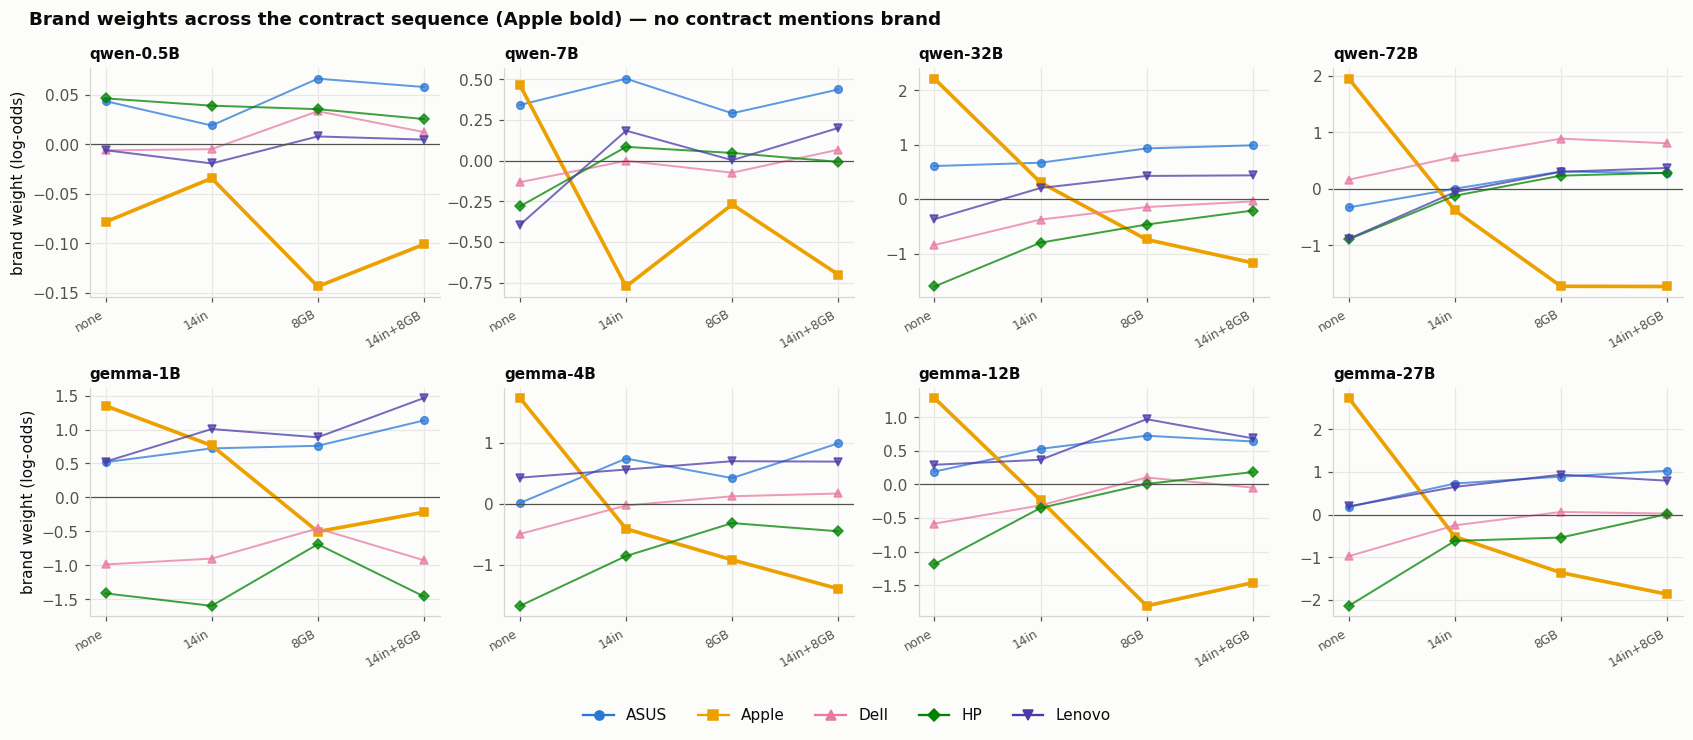

Apple's brand weight per phase (log-odds), and how far it travels:
           none  14in   8GB  14in+8GB  swing
model                                       
qwen-0.5B -0.08 -0.03 -0.14     -0.10   0.11
qwen-7B    0.46 -0.77 -0.27     -0.70   1.24
qwen-32B   2.21  0.30 -0.74     -1.17   3.38
qwen-72B   1.95 -0.38 -1.73     -1.73   3.68
gemma-1B   1.35  0.76 -0.50     -0.22   1.85
gemma-4B   1.73 -0.41 -0.92     -1.39   3.13
gemma-12B  1.28 -0.23 -1.80     -1.46   3.09
gemma-27B  2.74 -0.52 -1.36     -1.87   4.60


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(15.5, 6.6))
for ax, (fam, s) in zip(axes.ravel(), ALL):
    for b in BRANDS:
        y = [FITS[(fam, s, c)].weights_["brand"][b] for c in CON]
        ax.plot(range(4), y, "-", marker=BRAND_MARKER[b], color=BRAND_COLOR[b],
                ms=5, lw=2.4 if b == "Apple" else 1.3,
                alpha=1.0 if b == "Apple" else .75)
    ax.axhline(0, color=INK_MUTED, lw=.8)
    ax.set_xticks(range(4), cols, rotation=30, ha="right", fontsize=8)
    ax.set_title(lbl(fam, s), loc="left", fontweight="bold", fontsize=10)
axes[0, 0].set_ylabel("brand weight (log-odds)")
axes[1, 0].set_ylabel("brand weight (log-odds)")
fig.legend(handles=[Line2D([], [], marker=BRAND_MARKER[b], color=BRAND_COLOR[b], label=b)
                    for b in BRANDS], ncol=5, loc="lower center", frameon=False,
           bbox_to_anchor=(.5, -.02))
fig.suptitle("Brand weights across the contract sequence (Apple bold) — "
             "no contract mentions brand", x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, .05, 1, 1])
save(fig, "s06_brand_trajectories")
plt.show()

print("Apple's brand weight per phase (log-odds), and how far it travels:")
ap = pd.DataFrame([dict(model=lbl(f, s),
                        **{CLAB[c]: FITS[(f, s, c)].weights_["brand"]["Apple"] for c in CON})
                   for f, s in ALL]).set_index("model")
ap["swing"] = ap.max(axis=1) - ap.min(axis=1)
print(ap.round(2).to_string())

---
# Fig 12.1 — the positional bias against the thing we are trying to measure

**Which pairs.** All of them: this compares the fitted parameters of the unconstrained
(`none`) run. Bars are the **range** $\max_\ell w_f(\ell) - \min_\ell w_f(\ell)$, i.e. the
largest effect that feature can have on a single prediction. The marker is $|\gamma|$, the
effect of being in slot A rather than slot B — a pure artefact of how the question is asked.

**What changed.** The old version plotted the *fitted* intercept, which is $\gamma - C$. With
the PMI constant added back, the positional bias is much smaller, and the headline claim
("the bias is bigger than every brand effect") **stops being true for some models**. The
hollow marker is the old number, the filled one is the corrected one, so the size of the
mistake is visible.

**qwen-0.5B has no marker**: it never saturates, so its $C$ — and therefore its $\gamma$ —
cannot be recovered from the stored scores. It would have to be measured directly.

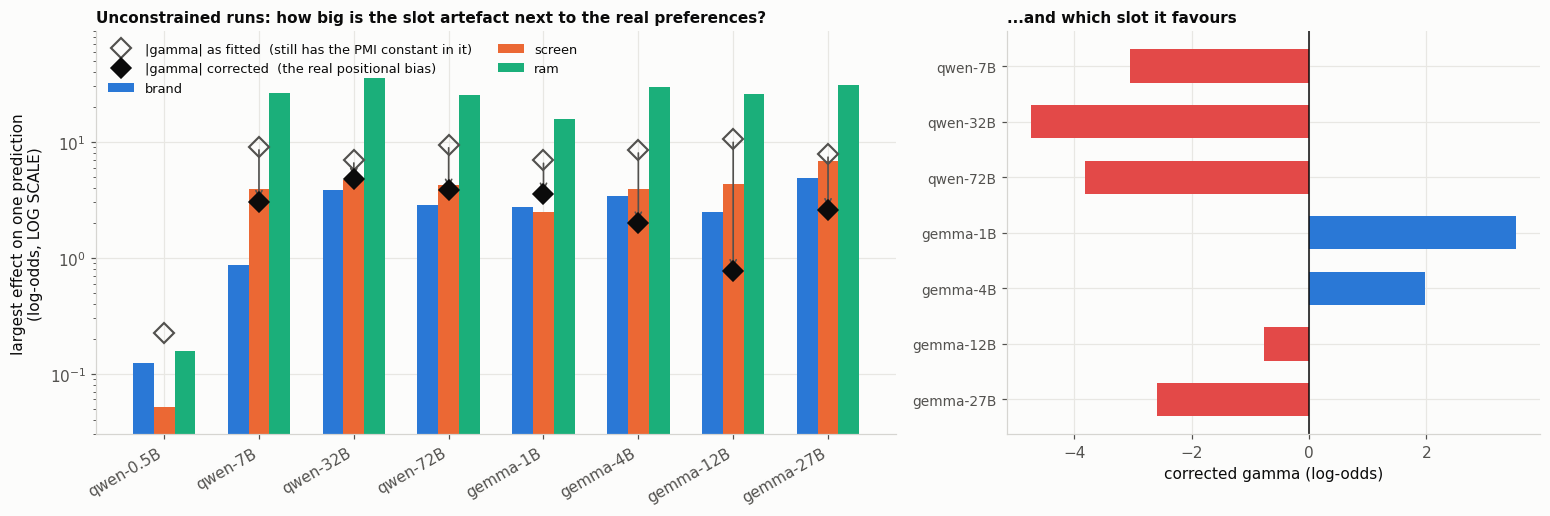

           g_fit  g_true  g_signed  brand  screen    ram gamma > brand?
model                                                                  
qwen-0.5B   0.22     NaN       NaN   0.12    0.05   0.16        unknown
qwen-7B     9.05    3.05     -3.05   0.86    3.90  26.53            yes
qwen-32B    6.98    4.73     -4.73   3.82    4.65  35.19            yes
qwen-72B    9.44    3.81     -3.81   2.84    4.26  25.39            yes
gemma-1B    6.94    3.53      3.53   2.76    2.48  15.64            yes
gemma-4B    8.51    1.99      1.99   3.41    3.94  29.99             no
gemma-12B  10.52    0.77     -0.77   2.47    4.29  25.92             no
gemma-27B   7.83    2.59     -2.59   4.88    6.78  30.93             no

corrected: the positional bias beats the whole brand range for 4 of 7 models with a recoverable gamma (as fitted, it was all of them).


In [8]:
none_fits = {(f, s): FITS[(f, s, "none")] for f, s in ALL}
piv = pd.DataFrame([dict(model=lbl(f, s),
                         **{ft: none_fits[(f, s)].range(ft) for ft in LEVELS},
                         g_fit=abs(none_fits[(f, s)].gamma_fit_),
                         g_true=abs(none_fits[(f, s)].gamma_),
                         g_signed=none_fits[(f, s)].gamma_)
                    for f, s in ALL]).set_index("model")

fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.8),
                         gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
x = np.arange(len(piv))
for i, ft in enumerate(["brand", "screen", "ram"]):
    ax.bar(x + (i - 1) * .22, piv[ft], .22, color=FEATURE_COLOR[ft], label=ft, zorder=2)
ax.plot(x, piv.g_fit, "D", mfc="none", mec=INK_MUTED, mew=1.4, ms=9, ls="none",
        label="|gamma| as fitted  (still has the PMI constant in it)", zorder=4)
ax.plot(x, piv.g_true, "D", color=INK, ms=9, ls="none",
        label="|gamma| corrected  (the real positional bias)", zorder=5)
for xi, (lo, hi) in enumerate(zip(piv.g_true, piv.g_fit)):
    if np.isfinite(lo):
        ax.annotate("", xy=(xi, lo), xytext=(xi, hi),
                    arrowprops=dict(arrowstyle="->", color=INK_MUTED, lw=1.1))
ax.set_xticks(x, piv.index, rotation=30, ha="right")
# log scale: ram spans 15-35 while the comparison that matters (gamma vs brand) lives
# between 0.8 and 5, and on a linear axis that comparison is an unreadable smudge.
ax.set_yscale("log")
ax.set_ylim(0.03, 90)
ax.set_ylabel("largest effect on one prediction\n(log-odds, LOG SCALE)")
ax.set_title("Unconstrained runs: how big is the slot artefact next to the real preferences?",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", ncol=2)

ax = axes[1]
sign_ok = piv.dropna(subset=["g_signed"])
y = np.arange(len(sign_ok))
ax.barh(y, sign_ok.g_signed, .6,
        color=[VIOLATE if v < 0 else SATISFY for v in sign_ok.g_signed], zorder=2)
ax.axvline(0, color=INK, lw=1)
ax.set_yticks(y, sign_ok.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("corrected gamma (log-odds)")
ax.set_title("...and which slot it favours", loc="left", fontweight="bold", fontsize=10)
fig.tight_layout()
save(fig, "s12_gamma_vs_features")
plt.show()

piv["gamma > brand?"] = np.where(piv.g_true.isna(), "unknown",
                                 np.where(piv.g_true > piv.brand, "yes", "no"))
print(piv[["g_fit", "g_true", "g_signed", "brand", "screen", "ram", "gamma > brand?"]]
      .round(2).to_string())
n_ok = piv.g_true.notna().sum()
n_big = (piv.g_true > piv.brand).sum()
print(f"\ncorrected: the positional bias beats the whole brand range for {n_big} of "
      f"{n_ok} models with a recoverable gamma (as fitted, it was all of them).")